## Lista 3

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

In [28]:
f = pd.read_csv("Heart_disease_cleveland_new.csv")
print(f.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


age           
sex          
cp            chest pain 1-3
trestbps      blood pressure 
chol          cholesterol
fbs           blood sugar 0-1
restecg       Result of electrocardiogram 0-2 (więcej gorzej)
thalach       Maximum heart rate
exang         Angina 0-1
oldpeak       Obniżenie odcinka ST 
slope         Nachylenie odcinka ST
ca            The number of major vessels 
thal          A blood disorder 0-1
target        Klasa (chory/zdrowy)

In [29]:
sick = f[f.target == 1]
healthy = f[f.target == 0]
print(sick.shape[0] / (healthy.shape[0]+sick.shape[0]))

0.45874587458745875


In [30]:
X = f.drop('target', axis=1)
y = f['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Zadanie 2


In [31]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

/home/raf/dev/axion/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Zadanie 3


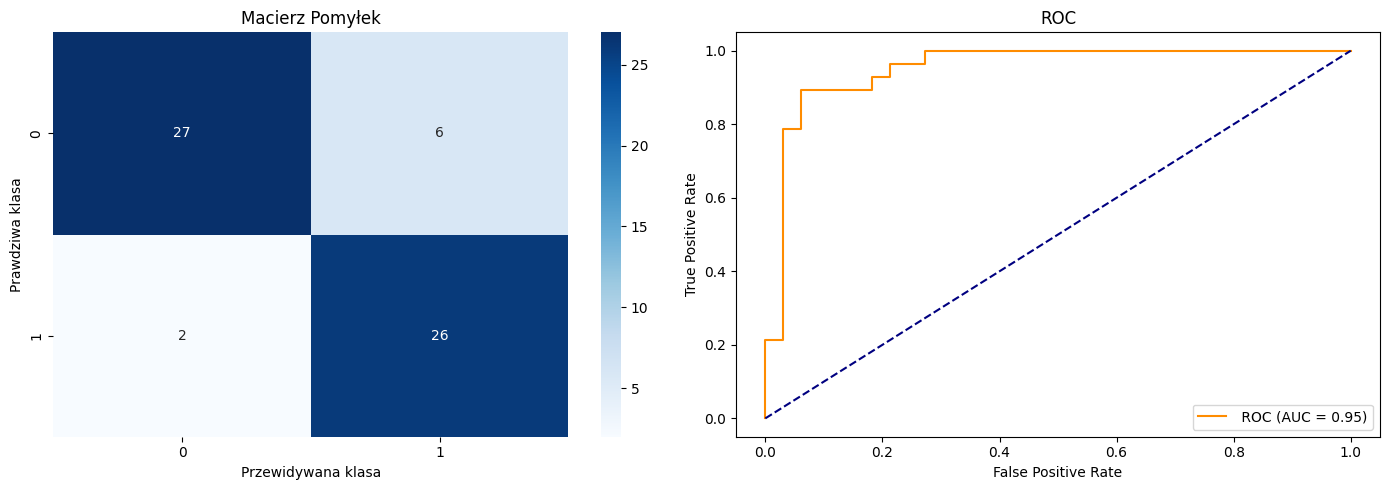

Precision: 0.8125
Recall: 0.9286
Accuracy: 0.8689



In [32]:
cm = confusion_matrix(y_test, y_pred)

y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Macierz Pomyłek")
axes[0].set_xlabel("Przewidywana klasa")
axes[0].set_ylabel("Prawdziwa klasa")


axes[1].plot(fpr, tpr, color='darkorange', label=f' ROC (AUC = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}\n")

## Zadnie 4


In [33]:
acc_original = accuracy_score(y_test, y_pred)



scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

clf_std = LogisticRegression(max_iter=1000, random_state=42)
clf_std.fit(X_train_std, y_train)
y_pred_std = clf_std.predict(X_test_std)
acc_std = accuracy_score(y_test, y_pred_std)



scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm = scaler_minmax.transform(X_test)

clf_norm = LogisticRegression(max_iter=1000, random_state=42)
clf_norm.fit(X_train_norm, y_train)
y_pred_norm = clf_norm.predict(X_test_norm)
acc_norm = accuracy_score(y_test, y_pred_norm)


print("ACC:")
print(f"Org:{acc_original:.4f}")
print(f"Std:{acc_std:.4f}")
print(f"Norm:{acc_norm:.4f}")

print("\nLiczba iteracji")
print(f"Org:{clf.n_iter_[0]}")
print(f"Std:{clf_std.n_iter_[0]}")
print(f"Norm:{clf_norm.n_iter_[0]}")

ACC:
Org:0.8689
Std:0.8689
Norm:0.8525

Liczba iteracji
Org:1000
Std:9
Norm:18


## Zadnie 5


In [34]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

C = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

accs = []
iters = []
print(f"{'C':<8} | {'Acc':<8} | {'Iter'}")

for c in C:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train_std, y_train)
    
    y_pred_c = model.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred_c)
    n_iter = model.n_iter_[0]

    accs.append(acc)
    iters.append(n_iter)
    

    print(f"{c:<8} | {acc:<8.4f} | {n_iter}")

C        | Acc      | Iter
0.0001   | 0.5410   | 6
0.001    | 0.8689   | 7
0.01     | 0.8852   | 8


0.1      | 0.8689   | 7
1        | 0.8689   | 9
10       | 0.8689   | 11
100      | 0.8689   | 11
1000     | 0.8689   | 11


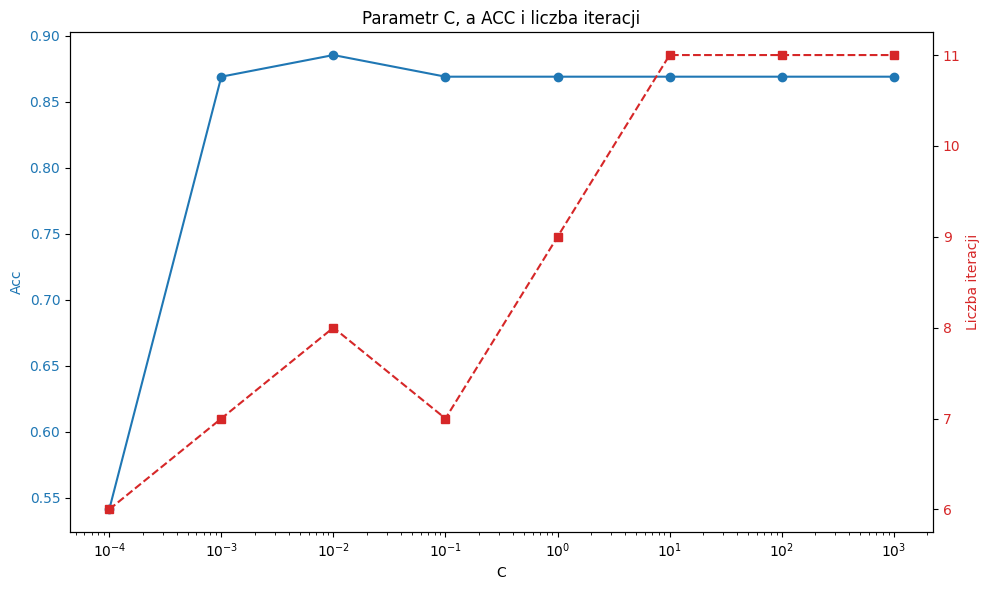

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xscale('log')
ax1.set_xlabel('C')

color_acc = 'tab:blue'
ax1.set_ylabel('Acc', color=color_acc)
ax1.plot(C, accs, marker='o', color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)


ax2 = ax1.twinx()  
color_iter = 'tab:red'
ax2.set_ylabel('Liczba iteracji', color=color_iter)
ax2.plot(C, iters, marker='s', linestyle='--', color=color_iter)
ax2.tick_params(axis='y', labelcolor=color_iter)

plt.title('Parametr C, a ACC i liczba iteracji')
fig.tight_layout()
plt.show()

## Zadnie 6

In [ ]:
X_all = f.drop('target', axis=1)
y_all = f['target']

clf_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

folds = [2, 5, 10]

kfold_means, kfold_stds = [], []
stratified_means, stratified_stds = [], []

print(f"{'Folds':<5} | {'Mean ACC ':<16} | {'Mean ACC (Stratified)'}")

for k in folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kf = cross_val_score(clf_pipeline, X_all, y_all, cv=kf, scoring='accuracy')
    kfold_means.append(np.mean(scores_kf))
    kfold_stds.append(np.std(scores_kf))

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_skf = cross_val_score(clf_pipeline, X_all, y_all, cv=skf, scoring='accuracy')
    stratified_means.append(np.mean(scores_skf))
    stratified_stds.append(np.std(scores_skf))
    
    print(f"{k:<5} | {np.mean(scores_kf):<4.4f}  ± {np.std(scores_kf):<6.4f} | {np.mean(scores_skf):<4.4f}  ± {np.std(scores_skf):.4f}")



Folds | Mean ACC         | Mean ACC (Stratified)
2     | 0.8251  ± 0.0039 | 0.8184  ± 0.0105
5     | 0.8415  ± 0.0293 | 0.8316  ± 0.0496
10    | 0.8383  ± 0.0541 | 0.8345  ± 0.0638


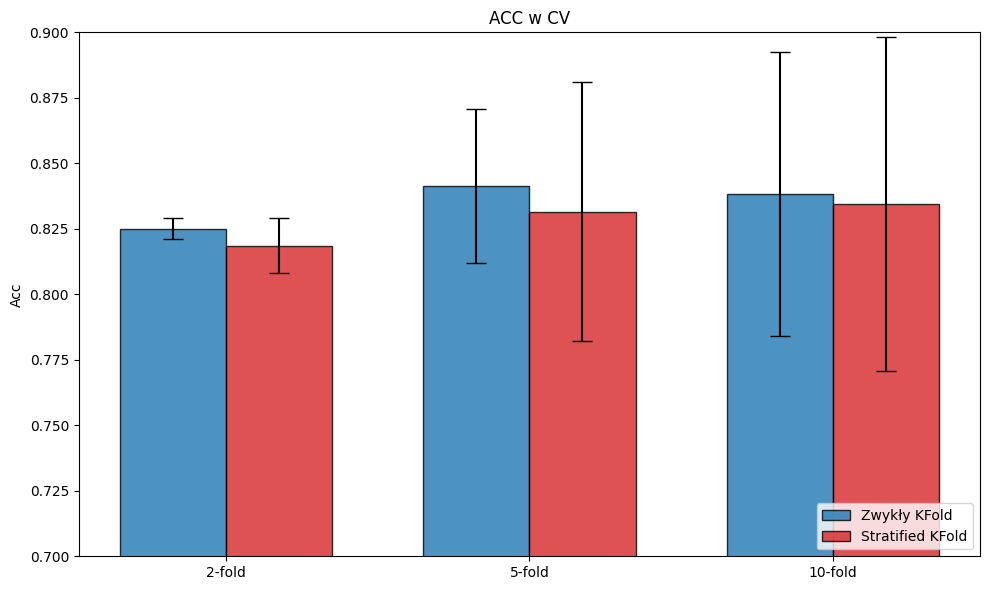

In [64]:
x = np.arange(len(folds)) 
width = 0.35          
fig, ax = plt.subplots(figsize=(10, 6))

color_kfold = 'tab:blue'
color_strat = 'tab:red'

ax.bar(x - width/2, kfold_means, width, yerr=kfold_stds, 
       label='Zwykły KFold', color=color_kfold, capsize=7, alpha=0.8, edgecolor='black')

ax.bar(x + width/2, stratified_means, width, yerr=stratified_stds, 
       label='Stratified KFold', color=color_strat, capsize=7, alpha=0.8, edgecolor='black')

ax.set_ylabel('Acc')
ax.set_ylim([0.7, 0.9]) 


ax.set_xticks(x)
ax.set_xticklabels([f'{k}-fold' for k in folds])


ax.set_title('ACC w CV')
ax.legend(loc='lower right')

fig.tight_layout()
plt.show()